In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load correct sheet (sir ne jo bola)
df = pd.read_excel('/content/heart_disease.xlsx', sheet_name=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [4]:
# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,2.3,0,True,False,False,True,False,False,False,False,False,False,False,False,False
1,41,135,203,False,132,0.0,0,True,True,False,False,True,False,False,False,False,True,False,False,False
2,57,140,192,False,148,0.4,0,True,False,False,False,True,False,False,False,False,True,False,False,False
3,52,118,186,False,190,0.0,0,True,False,False,True,False,False,False,False,False,True,False,False,False
4,57,110,201,False,126,1.5,0,True,False,False,False,True,False,True,False,False,True,False,False,False


In [5]:
df.shape

(908, 20)

In [6]:
df.isnull().sum()

,0
age,0
trestbps,0
chol,0
fbs,0
thalch,0
oldpeak,62
num,0
sex_Male,0
cp_atypical angina,0
cp_non-anginal,0


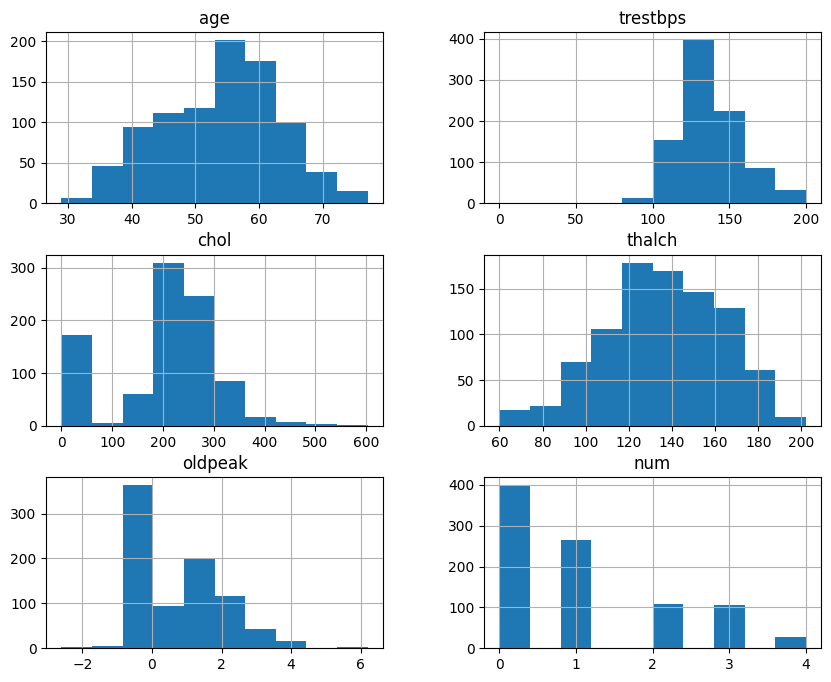

In [7]:
df.hist(figsize=(10,8))
plt.show()

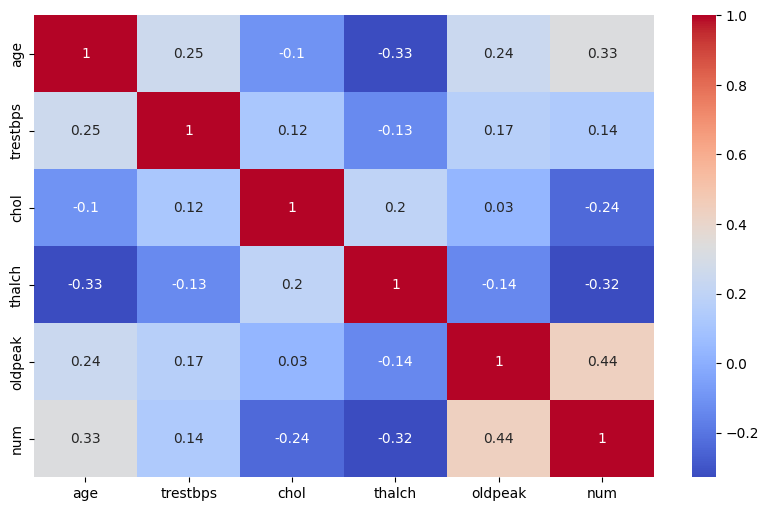

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.show()

In [20]:
# Check columns first
print(df.columns)

# Change 'target' if needed
X = df.drop('num', axis=1)
y = df['num']

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak', 'num',
       'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'exang_FALSE', 'exang_TURE', 'slope_flat', 'slope_upsloping',
       'thal_normal', 'thal_reversable defect'],
      dtype='object')


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
df['sex_Male'] = df['sex_Male'].astype(int)

df.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,2.3,0,1,False,False,True,False,False,False,False,False,False,False,False,False
1,41,135,203,False,132,0.0,0,1,True,False,False,True,False,False,False,False,True,False,False,False
2,57,140,192,False,148,0.4,0,1,False,False,False,True,False,False,False,False,True,False,False,False
3,52,118,186,False,190,0.0,0,1,False,False,True,False,False,False,False,False,True,False,False,False
4,57,110,201,False,126,1.5,0,1,False,False,False,True,False,True,False,False,True,False,False,False


In [23]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.45054945054945056

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.69      0.67        89
           1       0.24      0.25      0.25        48
           2       0.14      0.09      0.11        22
           3       0.35      0.41      0.38        17
           4       0.00      0.00      0.00         6

    accuracy                           0.45       182
   macro avg       0.28      0.29      0.28       182
weighted avg       0.44      0.45      0.44       182



In [25]:
model2 = DecisionTreeClassifier(max_depth=5, random_state=42)
model2.fit(X_train, y_train)

print("Tuned Accuracy:", accuracy_score(y_test, model2.predict(X_test)))

Tuned Accuracy: 0.5384615384615384


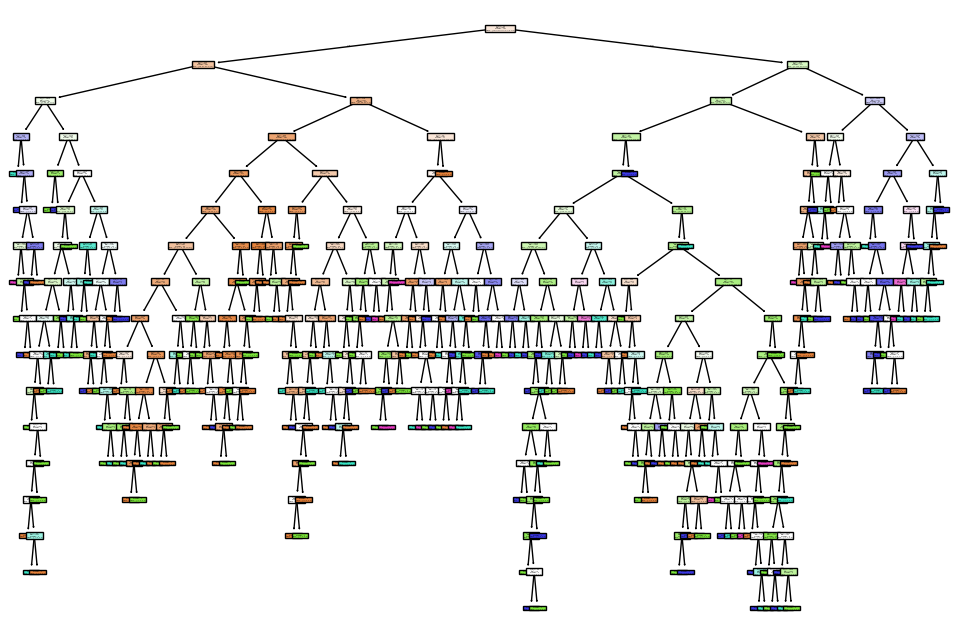

In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

In [27]:
# Feature Engineering

# Convert categorical data to numeric
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,2.3,0,1,False,False,True,False,False,False,False,False,False,False,False,False
1,41,135,203,False,132,0.0,0,1,True,False,False,True,False,False,False,False,True,False,False,False
2,57,140,192,False,148,0.4,0,1,False,False,False,True,False,False,False,False,True,False,False,False
3,52,118,186,False,190,0.0,0,1,False,False,True,False,False,False,False,False,True,False,False,False
4,57,110,201,False,126,1.5,0,1,False,False,False,True,False,True,False,False,True,False,False,False


In [28]:
# Hyperparameter Tuning

from sklearn.tree import DecisionTreeClassifier

model_tuned = DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)
model_tuned.fit(X_train, y_train)

y_pred_tuned = model_tuned.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.5384615384615384


## Interview Questions

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Some common hyperparameters of decision tree models are:
- max_depth: Controls the maximum depth of the tree. If depth is too high, the model may overfit.
- min_samples_split: Minimum number of samples required to split a node. Higher value reduces overfitting.
- criterion: Measures the quality of a split (e.g., 'gini' or 'entropy').

These hyperparameters help in controlling the complexity of the model and improving its performance by reducing overfitting.


2. What is the difference between Label encoding and One-hot encoding?

Label Encoding:
- Converts categories into numbers (e.g., Male = 1, Female = 0)
- Suitable for ordinal data

One-hot Encoding:
- Creates separate binary columns for each category
- Suitable for nominal data

Difference:
Label encoding assigns a numeric order, while one-hot encoding treats each category independently without any order.